A script to experiment with results.

## Data and Library Loading

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Prepare the Matrix
# Pivot: Rows = Models, Cols = Tags
df = pd.read_csv("clirener_aggregated_mean_std.csv")

# Filter for BERTs
df = df[df["model_display_name"].str.contains("BERT") | df["model_display_name"].str.contains("INDUS")]

matrix = df.pivot(index='model_display_name', columns='tag', values='strict_f1_mean').fillna(0)

# Optional: Drop rows that are completely empty/broken if desired, 
# but keeping them shows they are outliers (like SciClimateBERT in your data)

## Hierarchical Clustering by F1

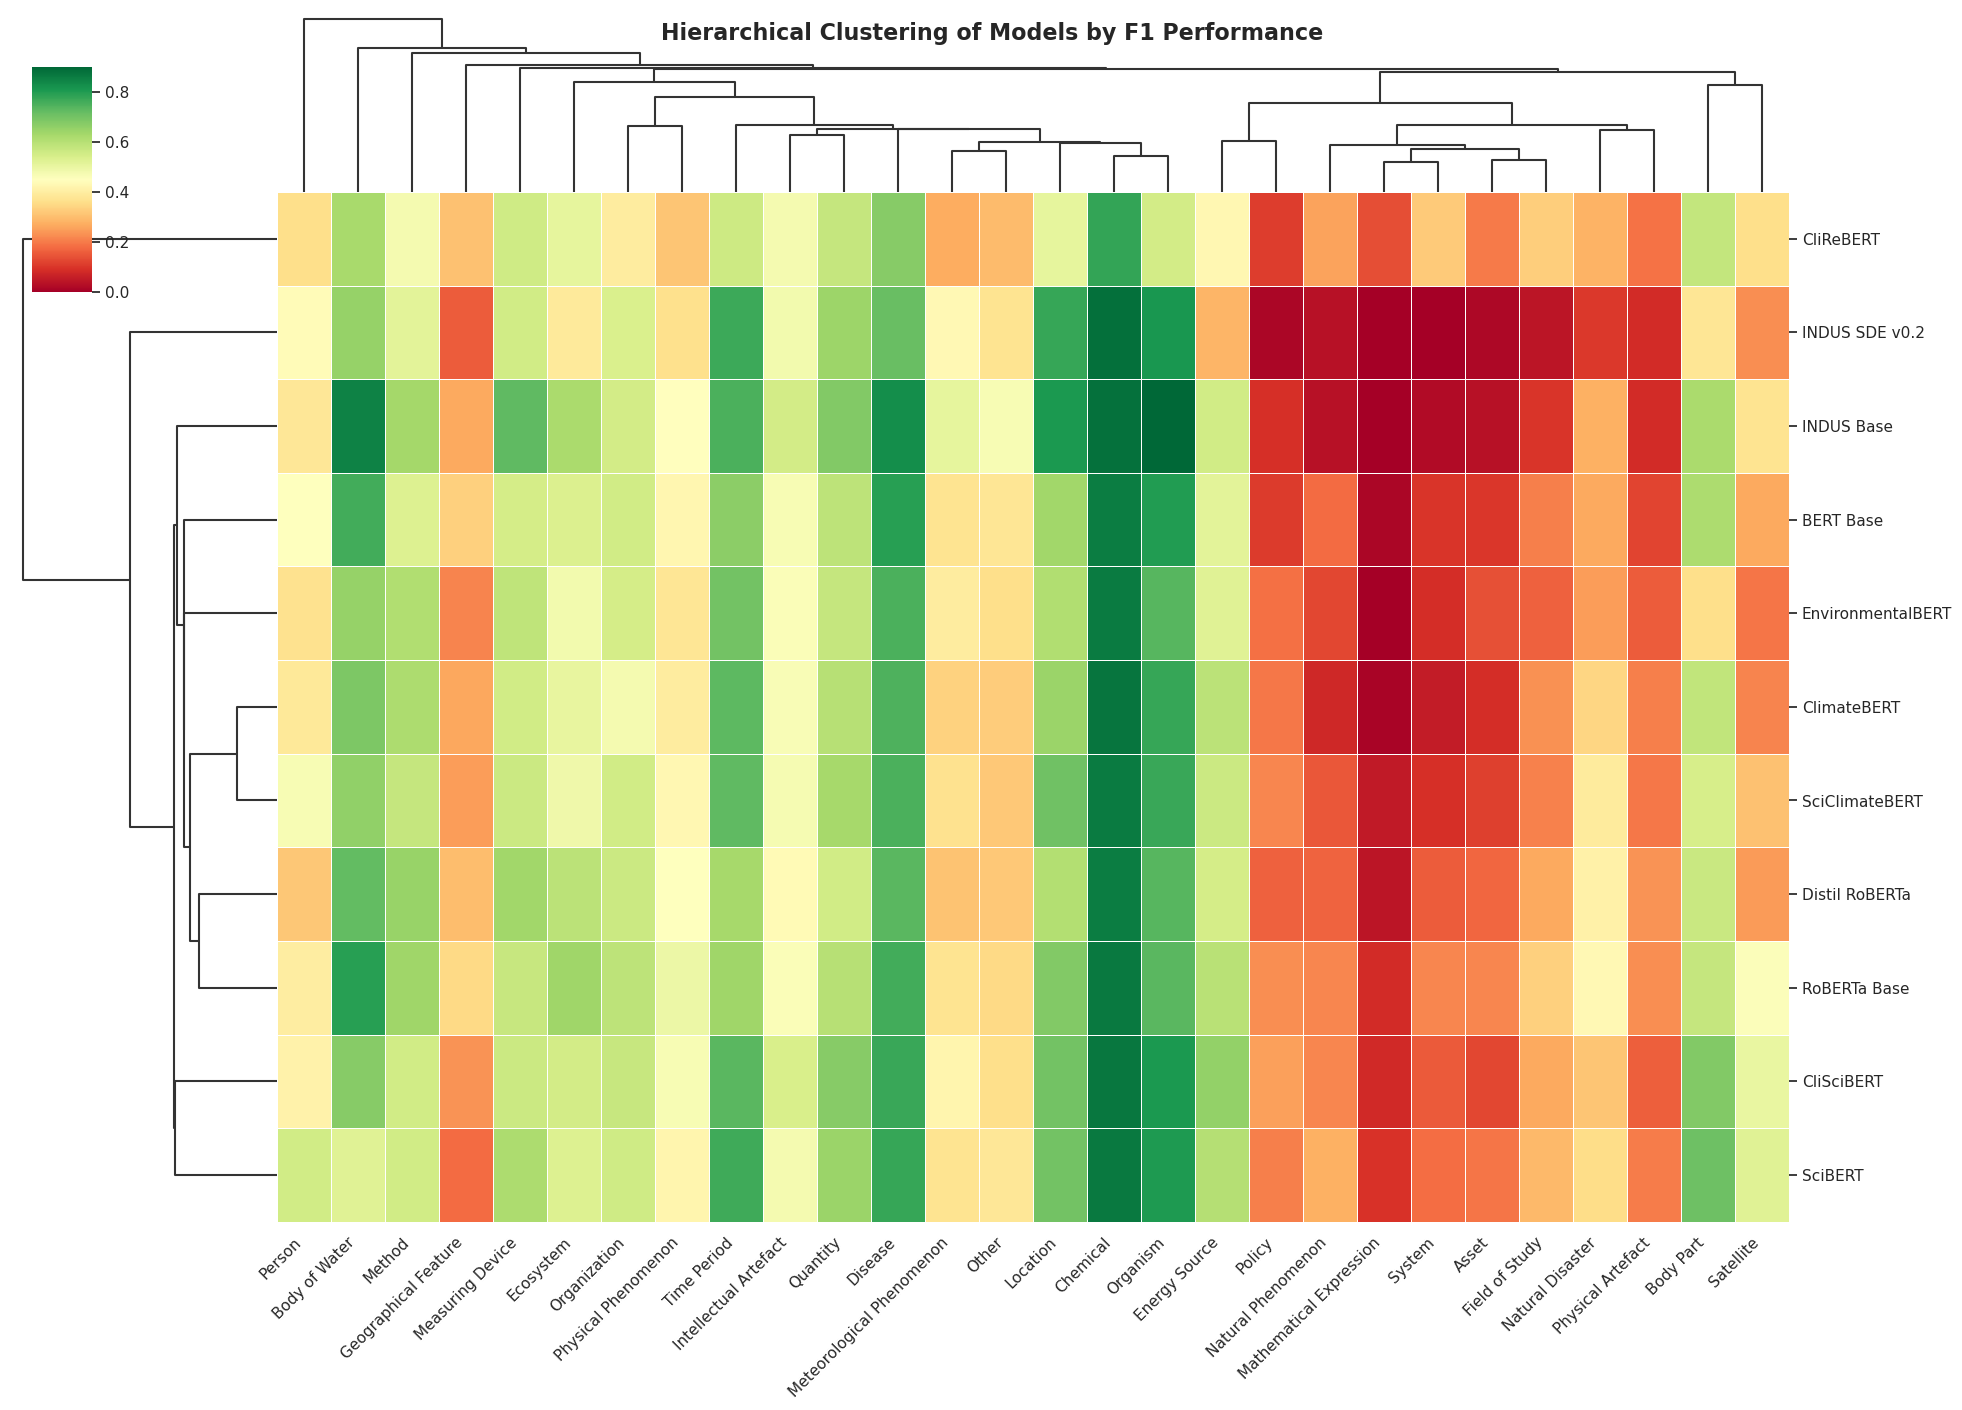

Cluster-Sorted Model List (Copy this to Vega-Lite 'sort'):
['CliReBERT', 'INDUS SDE v0.2', 'INDUS Base', 'BERT Base', 'EnvironmentalBERT', 'ClimateBERT', 'SciClimateBERT', 'Distil RoBERTa', 'RoBERTa Base', 'CliSciBERT', 'SciBERT']


In [11]:
# Set general aesthetic
sns.set_theme(style="white")

# Create the clustermap
g = sns.clustermap(
    matrix,
    method='single',           # Ward's method minimizes variance within clusters
    metric='correlation',
    cmap="RdYlGn",           # Yellow-Green-Blue is colorblind friendly and clean
    figsize=(20, 15),        # Large size for readability
    dendrogram_ratio=(0.15, 0.15), # Control size of the tree diagram
    cbar_pos=(0.02, 0.8, 0.03, 0.15), # Move colorbar to top left (x, y, w, h)
    linewidths=0.5,          # Grid lines
    linecolor='white',
    tree_kws=dict(linewidths=1.5)
)

# Adjust axes
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=11)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=11)

# Add Title (moved slightly to not overlap dendrogram)
g.fig.suptitle('Hierarchical Clustering of Models by F1 Performance', y=0.98, fontsize=16, fontweight='bold')

plt.show()

# --- EXTRACT THE SORTED ORDER ---
# This is the magic list you need for your Vega-Lite Y-axis sort
reordered_indices = g.dendrogram_row.reordered_ind
sorted_models = matrix.index[reordered_indices].tolist()
print("Cluster-Sorted Model List (Copy this to Vega-Lite 'sort'):")
print(sorted_models)

## PCA-based analysis

In [4]:
# 1. Calculate PCA (2D projection)
pca = PCA(n_components=2)
components = pca.fit_transform(matrix)

# 2. Calculate Clusters (Auto-detect e.g., 4 groups)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(matrix)

# 3. Create DataFrame for Plotting
plot_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'], index=matrix.index)
plot_df['Cluster'] = clusters.astype(str)
plot_df['Model'] = plot_df.index
plot_df['Mean_F1'] = matrix.mean(axis=1) # Calculate overall mean for hover info

# 4. Plot
fig = px.scatter(
    plot_df, 
    x='PC1', 
    y='PC2', 
    color='Cluster',
    symbol='Cluster',
    hover_name='Model',
    hover_data={'Mean_F1': ':.3f', 'PC1': False, 'PC2': False, 'Cluster': False},
    title='Model Similarity Map (PCA)',
    template='plotly_white',
    width=1000,
    height=700,
    size_max=15
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    legend_title_text='Detected Group',
    xaxis_title="Principal Component 1 (Overall Performance)",
    yaxis_title="Principal Component 2 (Specialization Pattern)"
)

fig.show()

## Specialization Analysis

Based on deviation from average.

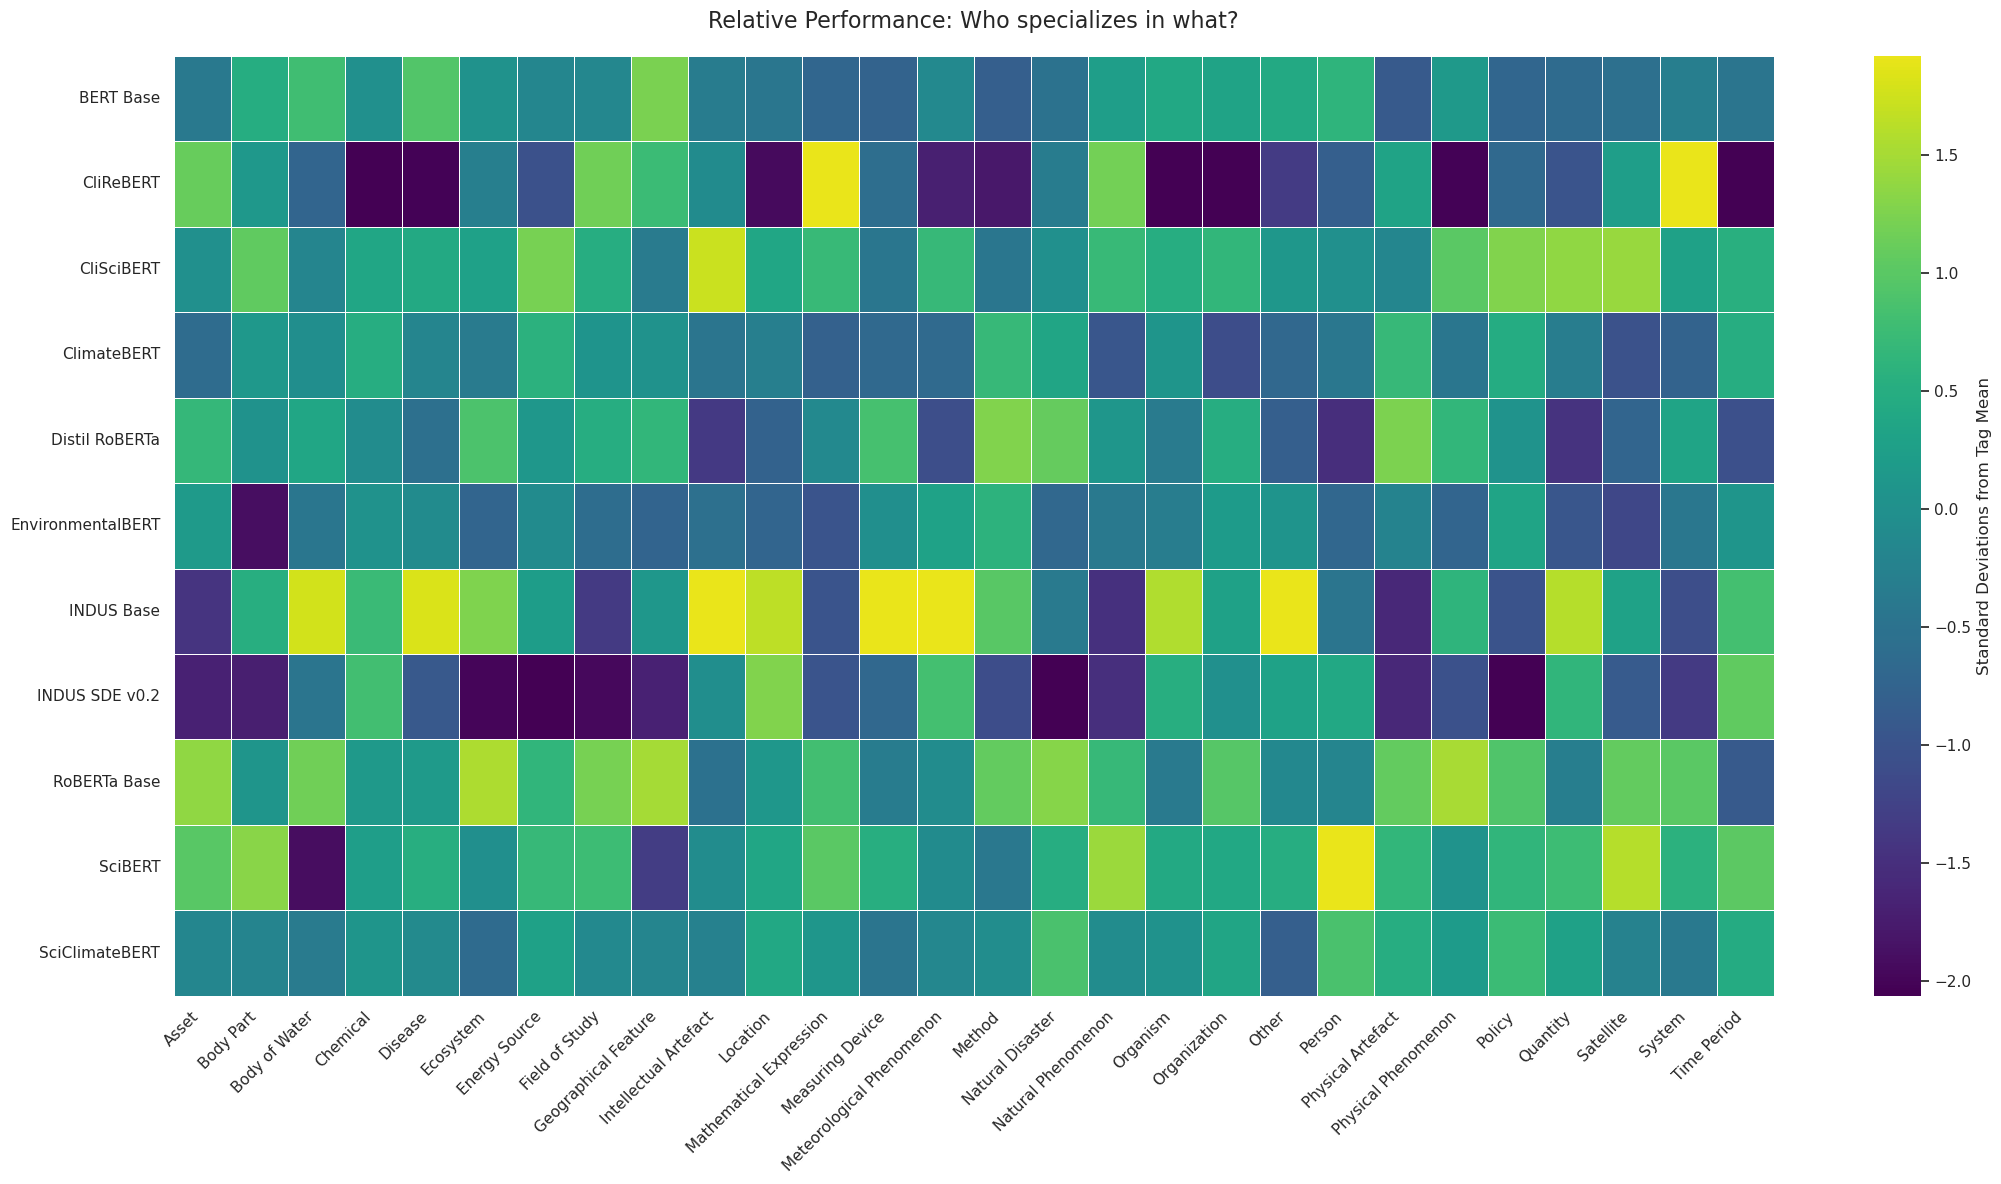

In [12]:
# Calculate Z-score (standardized deviation from the mean of that tag)
# (Value - Mean) / StdDev
z_matrix = (matrix - matrix.mean()) / matrix.std()

plt.figure(figsize=(22, 12))
sns.heatmap(
    z_matrix, 
    cmap="viridis", # Red-White-Blue diverging palette (Reversed so Blue is high)
    center=0,      # White = Average performance
    robust=True,   # Ignore extreme outliers in color scaling
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Standard Deviations from Tag Mean'}
)

plt.title("Relative Performance: Who specializes in what?", fontsize=16, pad=20)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
z_matrix

tag,Asset,Body Part,Body of Water,Chemical,Disease,Ecosystem,Energy Source,Field of Study,Geographical Feature,Intellectual Artefact,...,Organization,Other,Person,Physical Artefact,Physical Phenomenon,Policy,Quantity,Satellite,System,Time Period
model_display_name,,,,,,,,,,,,,,,,,,,,,
BERT Base,-0.383562,0.488966,0.795518,-0.001581,0.940054,0.051234,-0.170058,-0.158244,1.235053,-0.342458,...,0.323245,0.425269,0.624228,-0.909623,0.153928,-0.713227,-0.633720,-0.566663,-0.313345,-0.456190
CliReBERT,1.098733,0.133445,-0.727914,-2.882753,-2.028547,-0.302554,-1.032921,1.160360,0.749865,-0.096986,...,-2.582979,-1.343765,-0.829208,0.332316,-2.014852,-0.669116,-0.973915,0.234673,2.107620,-2.069897
CliSciBERT,-0.014316,1.060080,-0.190390,0.378269,0.425716,0.277694,1.210653,0.490097,-0.360935,1.727218,...,0.646784,0.119390,-0.003210,-0.165000,0.994128,1.275807,1.362337,1.416740,0.297235,0.545627
ClimateBERT,-0.628923,0.146602,-0.046675,0.509611,-0.189504,-0.360384,0.577783,0.083403,0.044643,-0.458610,...,-1.098083,-0.688641,-0.419910,0.695352,-0.441931,0.468840,-0.322395,-1.011088,-0.761802,0.500335
Distil RoBERTa,0.685743,0.035077,0.376189,-0.071897,-0.559808,0.889591,0.121869,0.497870,0.647076,-1.371890,...,0.500156,-0.819549,-1.501699,1.239013,0.652539,0.060443,-1.444945,-0.737411,0.347575,-1.052734
EnvironmentalBERT,0.171605,-1.890822,-0.437613,0.042722,-0.088887,-0.725257,-0.095195,-0.614057,-0.745281,-0.561846,...,0.188912,0.069577,-0.703661,-0.213031,-0.725245,0.338190,-0.948093,-1.185976,-0.419570,0.088929
INDUS Base,-1.430233,0.526430,1.769116,0.730458,1.814476,1.264844,0.220047,-1.354351,0.120922,2.029327,...,0.295050,2.407113,-0.452840,-1.607746,0.625388,-0.999441,1.596323,0.315861,-1.091060,0.823624
INDUS SDE v0.2,-1.682552,-1.714871,-0.444057,0.810825,-0.917247,-1.990047,-2.461059,-1.961873,-1.678321,-0.040314,...,-0.000980,0.309617,0.408552,-1.600950,-1.020118,-2.066789,0.631185,-0.893266,-1.351148,1.053814
RoBERTa Base,1.372377,0.099950,1.168743,0.156807,0.177681,1.555048,0.635971,1.219735,1.485458,-0.532180,...,0.968170,-0.148395,-0.188967,1.066289,1.519725,0.911391,-0.314511,1.071759,0.993689,-0.901409


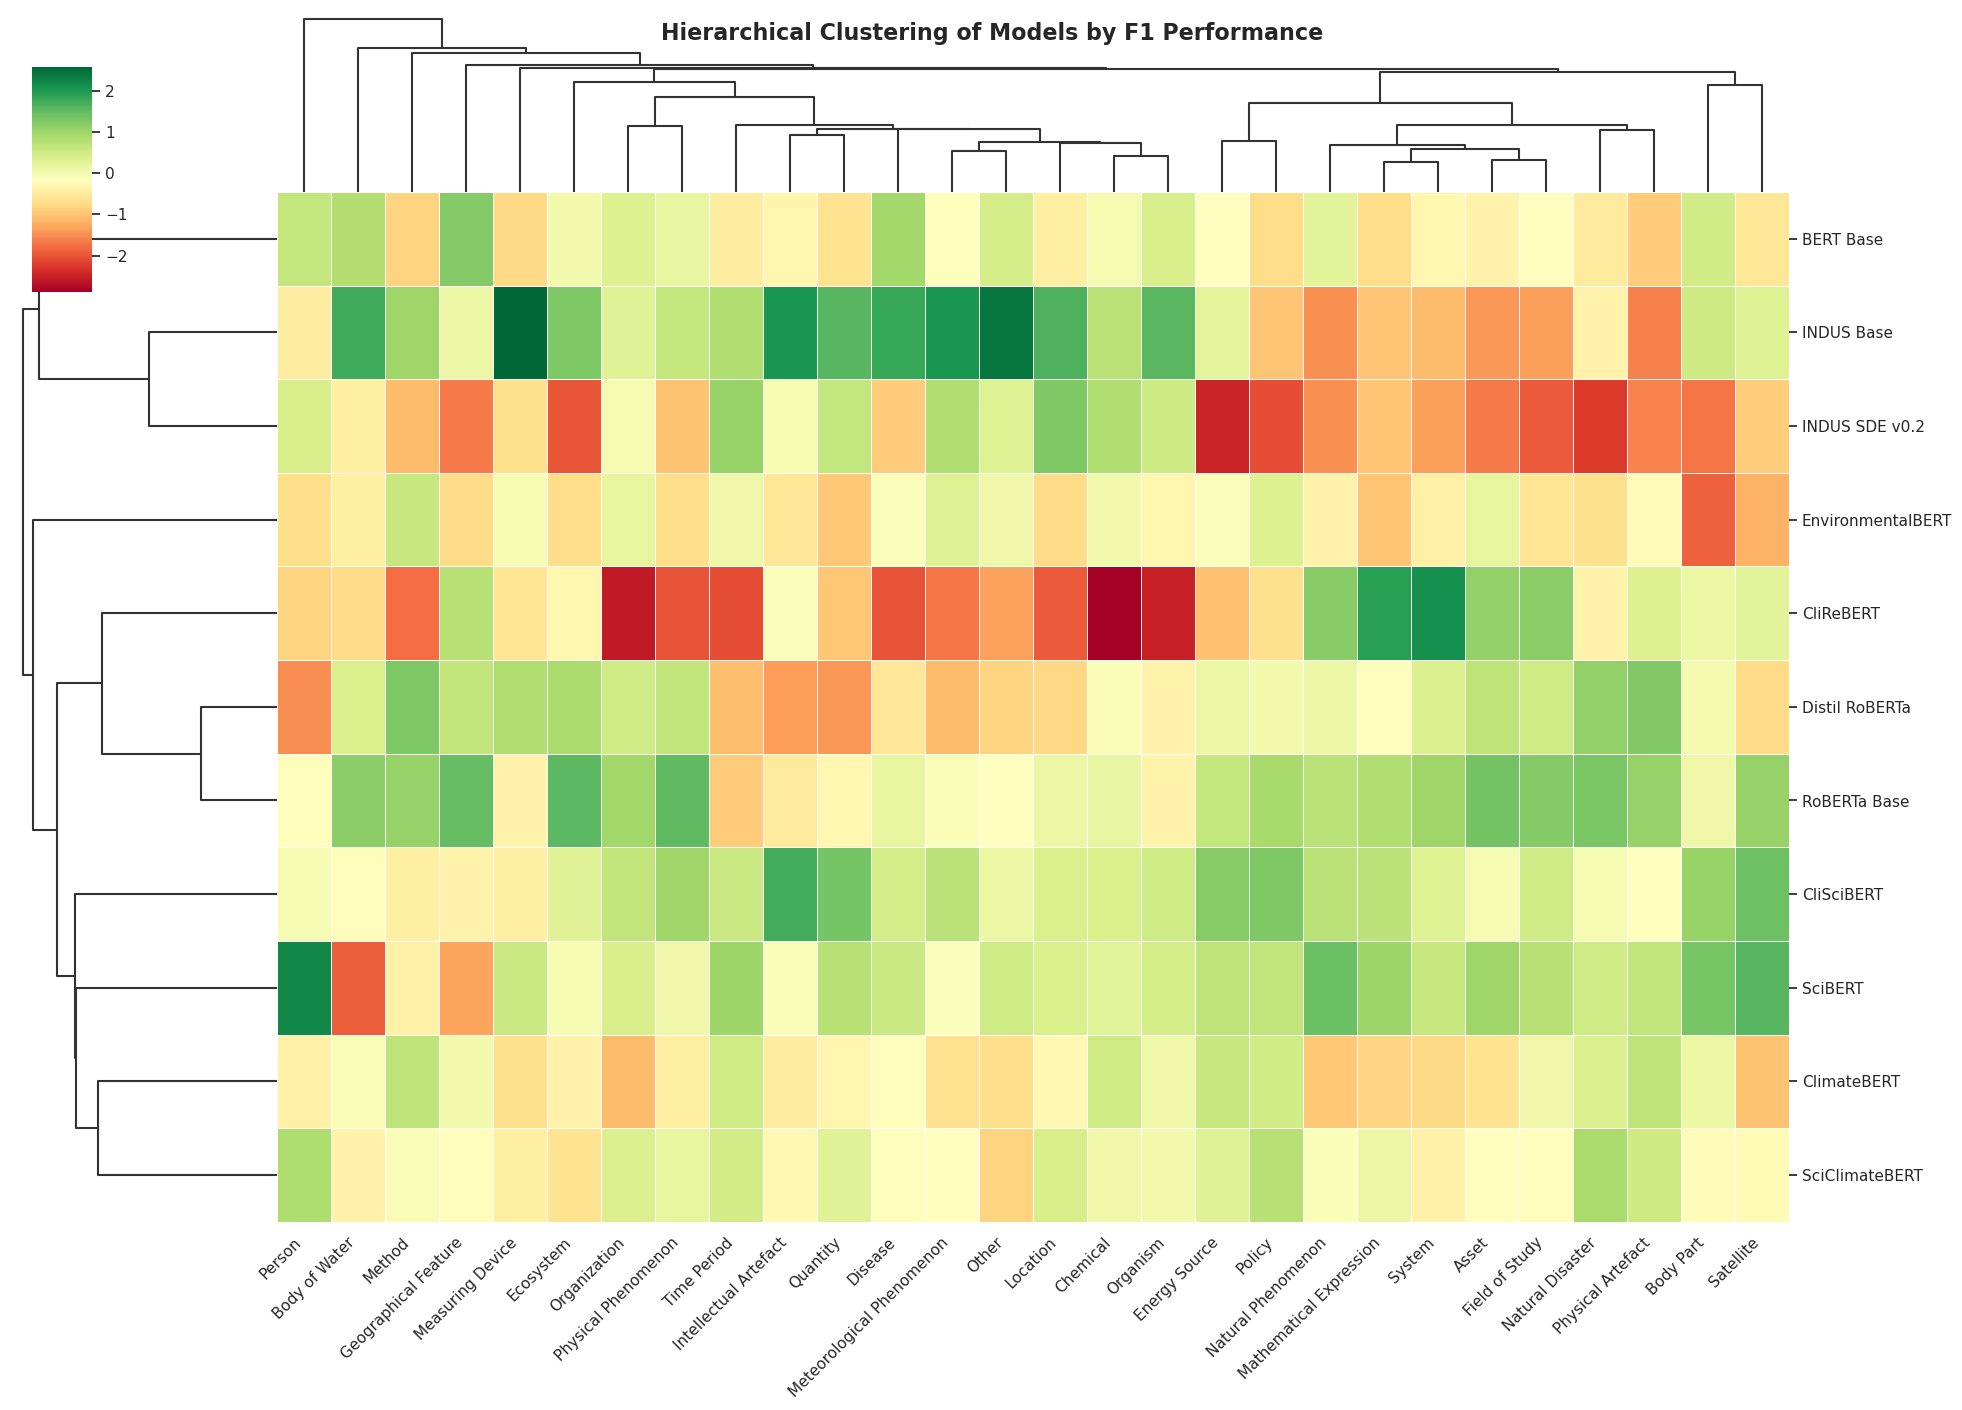

Cluster-Sorted Model List (Copy this to Vega-Lite 'sort'):
['BERT Base', 'INDUS Base', 'INDUS SDE v0.2', 'EnvironmentalBERT', 'CliReBERT', 'Distil RoBERTa', 'RoBERTa Base', 'CliSciBERT', 'SciBERT', 'ClimateBERT', 'SciClimateBERT']


In [16]:
# Set general aesthetic
sns.set_theme(style="white")

z_matrix = (matrix - matrix.mean()) / matrix.std()


# Create the clustermap
g = sns.clustermap(
    z_matrix,
    method='single',           # Ward's method minimizes variance within clusters
    metric='correlation',
    cmap="RdYlGn",           # Yellow-Green-Blue is colorblind friendly and clean
    figsize=(20, 15),        # Large size for readability
    dendrogram_ratio=(0.15, 0.15), # Control size of the tree diagram
    cbar_pos=(0.02, 0.8, 0.03, 0.15), # Move colorbar to top left (x, y, w, h)
    linewidths=0.5,          # Grid lines
    linecolor='white',
    tree_kws=dict(linewidths=1.5)
)

# Adjust axes
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=11)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=11)

# Add Title (moved slightly to not overlap dendrogram)
g.fig.suptitle('Hierarchical Clustering of Models by F1 Performance', y=0.98, fontsize=16, fontweight='bold')

plt.show()

# --- EXTRACT THE SORTED ORDER ---
# This is the magic list you need for your Vega-Lite Y-axis sort
reordered_indices = g.dendrogram_row.reordered_ind
sorted_models = matrix.index[reordered_indices].tolist()
print("Cluster-Sorted Model List (Copy this to Vega-Lite 'sort'):")
print(sorted_models)

## Web-chart Analysis

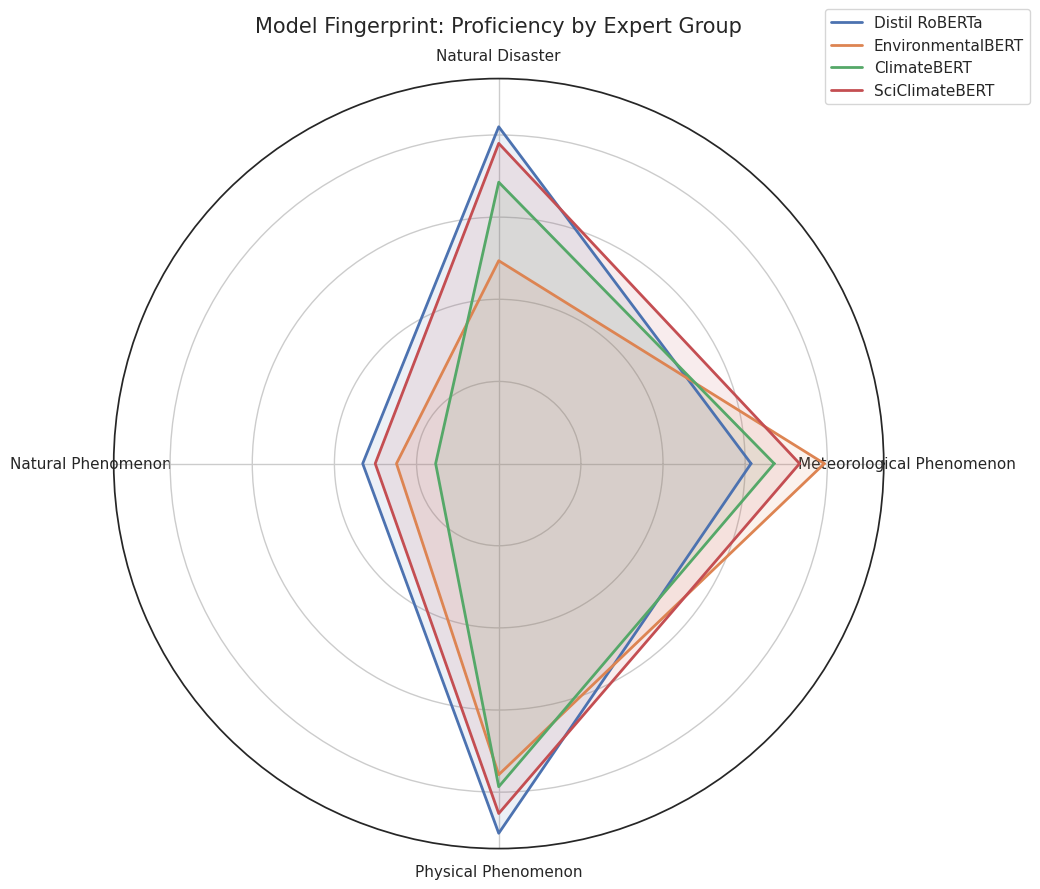

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your groups
groups = {
    "G1: Policy": ["Asset", "Policy"],
    "G2: Science": ["Method", "Field of Study", "Intellectual Artefact"],
    "G3: Geographical": ["Location", "Geographical Feature", "Body of Water", "Time Period"],
    
    "G4: Physics": ["Satellite", "Mathematical Expression", "Measuring Device", "Physical Phenomenon", "Quantity"],
    # "G3: Physics/Math": [],
    "G5: Biology/Environment": ["Body Part", "Organism", "Ecosystem"],
    "G6: Med/Chem": ["Chemical", "Disease", "Energy Source"],
    "G7: Meteorology": ["Meteorological Phenomenon",],
    "G5: Natural Events": ["Natural Disaster", "Natural Phenomenon"],
    "G6: Artifacts/Orgs": ["Physical Artefact", "Organization", "Person", "System"]
}



# Assuming you have a list of your tags
all_tags = [
    # "Asset", "Policy", 
    "Method", 
    # "Field of Study", "Intellectual Artefact",
    "Location", 
    # "Geographical Feature", "Body of Water", "Time Period",
    # "Satellite", "Mathematical Expression", 
    "Measuring Device", 
    # "Physical Phenomenon", 
    "Quantity", 
    # "Body Part", 
    "Organism", 
    # "Ecosystem", 
    "Chemical", 
    # "Disease", "Energy Source", 
    "Meteorological Phenomenon", 
    # "Natural Disaster", "Natural Phenomenon", 
    # "Physical Artefact", 
    "Organization", 
    # "Person", "System"
]

all_tags = [
    # "Asset", 
    "Policy", 
    # "Method", 
    "Field of Study", # "Intellectual Artefact",
    # "Location", 
    # "Geographical Feature", "Body of Water", 
    "Time Period",
    "Satellite", # "Mathematical Expression", 
    "Measuring Device", 
    # # "Physical Phenomenon", 
    # "Quantity", 
    "Body Part", 
    # "Organism", 
    # # "Ecosystem", 
    # "Chemical", 
    "Disease", 
    "Energy Source", 
    "Meteorological Phenomenon", 
    # # "Natural Disaster", 
    "Natural Phenomenon", 
    # # "Physical Artefact", 
    "Organization", 
    "Person", 
    "System"
]

all_tags = [
    "Asset", "Policy", "Method", "Field of Study", "Intellectual Artefact",
    "Location", "Geographical Feature", "Body of Water", "Time Period","Satellite", 
    "Mathematical Expression", "Measuring Device", "Physical Phenomenon", "Quantity", 
    "Body Part", "Organism", "Ecosystem", "Chemical", "Disease", 
    "Energy Source", "Meteorological Phenomenon",  "Natural Disaster", "Natural Phenomenon", 
    "Physical Artefact", "Organization", "Person", "System"
]

all_tags = [
    # "Asset", "Policy", "Method", "Field of Study", "Intellectual Artefact",
    # "Location", "Geographical Feature", "Body of Water", "Time Period","Satellite", 
    # "Mathematical Expression", "Measuring Device", 
    "Physical Phenomenon", 
    # "Quantity", 
    # "Body Part", "Organism", "Ecosystem", "Chemical", "Disease", 
    # "Energy Source", 
    "Meteorological Phenomenon",  "Natural Disaster", "Natural Phenomenon", 
    # "Physical Artefact", "Organization", "Person", "System"
]

# Create the dictionary dynamically
groups = {tag: [tag] for tag in all_tags}

# groups = {
#     # Proper Nouns / Standard NER types (Usually Easiest)
#     "Named Entities": [
#         "Person", "Organization", "Location", "Satellite", "Body of Water"
#     ],
    
#     # Concrete Technical Terms (Medium Difficulty)
#     "Scientific Terms": [
#         "Chemical", "Disease", "Organism", "Body Part", 
#         "Measuring Device", "Physical Artefact"
#     ],
    
#     # Measurements and Numbers
#     "Quantitative": [
#         "Quantity", "Mathematical Expression", "Time Period", "Energy Source"
#     ],
    
#     # Abstract Concepts (Usually Hardest - require understanding context)
#     "Abstract Concepts": [
#         "Method", "System", "Policy", "Asset", "Field of Study", 
#         "Intellectual Artefact", "Objective" # Added Objective if present
#     ],
    
#     # Environmental Events (Descriptive)
#     "Events & Phenomena": [
#         "Natural Disaster", "Natural Phenomenon", "Meteorological Phenomenon",
#         "Physical Phenomenon", "Geographical Feature", "Ecosystem"
#     ]
# }

# 2. Map tags to groups in the dataframe
tag_to_group = {tag: group for group, tags in groups.items() for tag in tags}
df['expert_group'] = df['tag'].map(tag_to_group)

# 3. Select 3 distinct models to compare (Avoid cluttering)
selected_models = [
    # "RoBERTa Base", 
    # "INDUS Base", "INDUS SDE v0.2",
    
    # "BERT Base", "SciBERT", "CliSciBERT", "CliReBERT",

    "Distil RoBERTa", "EnvironmentalBERT", "ClimateBERT",
    "SciClimateBERT",

    # "GLiNER: Small v2.5 ZS",
    # "GLiNER: Small v2.5",
    # "GLiNER: Medium v2.5 ZS",
    # "GLiNER: Medium v2.5",

    # "GPT 5.1 ZS",
    # "GPT 5.2 Pro ZS",
    # "DeepSeek-V3.2 (Non-Thinking) ZS",
    # "DeepSeek-V3.2 (Thinking) ZS",
    # "Claude Opus 4.5 ZS",
    # "Claude Sonnet 4.5 ZS",
    # "Gemini 3.0 Pro ZS",
    # "Gemini 2.5 Pro ZS"
]


subset = df[df['model_display_name'].isin(selected_models)]

# 4. Aggregate F1 by Model and Group
radar_data = subset.groupby(['model_display_name', 'expert_group'])['strict_f1_mean'].mean().unstack().fillna(0)

# 5. Build Radar Chart
labels = list(radar_data.columns)
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the loop

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for model in selected_models:
    values = radar_data.loc[model].tolist()
    values += values[:1] # Close the loop
    ax.plot(angles, values, linewidth=2, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
plt.title("Model Fingerprint: Proficiency by Expert Group", y=1.05, fontsize=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

## Model qualitative comparison

In [2]:
!pip3 install wandb

^C


c:\Users\Desktop\miniforge3\envs\clirener_finetune\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'dataset_processing'

In [27]:
text = "We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research [MASK]"# climate change research."

In [28]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline
import torch

# Load the pretrained model and tokenizer
model_name = "P0L3/clirebert_clirevocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

# Move model to GPU if available
device = 0 if torch.cuda.is_available() else -1

# Create a fill-mask pipeline
fill_mask = pipeline("fill-mask", model=model, tokenizer=tokenizer, device=device)

# Example input from scientific climate literature
# text = "The rapid growth of scientific literature on anthropogenic climate change necessitates automated information extraction to manage and synthesise complex, multi-scalar climate [MASK]."

# Run prediction
predictions = fill_mask(text)

# Show top predictions
print(model_name)
print(text)
print(10*">")
for p in predictions:
    print(f"{p['sequence']} — {p['score']:.4f}")


Device set to use cuda:0


P0L3/clirebert_clirevocab_uncased
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research [MASK]
>>>>>>>>>>
we release our datasets , guidelines , and fine - tuned models to support advanced knowledge extraction in the climate change research . — 0.9160
we release our datasets , guidelines , and fine - tuned models to support advanced knowledge extraction in the climate change research community — 0.0114
we release our datasets , guidelines , and fine - tuned models to support advanced knowledge extraction in the climate change research references — 0.0112
we release our datasets , guidelines , and fine - tuned models to support advanced knowledge extraction in the climate change research institute — 0.0063
we release our datasets , guidelines , and fine - tuned models to support advanced knowledge extraction in the climate change research acknowledgments — 0.0028


In [29]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline
import torch

# Load the pretrained model and tokenizer
model_name = "P0L3/cliscibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

# Move model to GPU if available
device = 0 if torch.cuda.is_available() else -1

# Create a fill-mask pipeline
fill_mask = pipeline("fill-mask", model=model, tokenizer=tokenizer, device=device)

# Example input from scientific climate literature
# text = "The rapid growth of scientific literature on anthropogenic climate change necessitates automated information extraction to manage and synthesise complex, multi-scalar climate [MASK]."

# Run prediction
predictions = fill_mask(text)

# Show top predictions
print(model_name)
print(text)
print(10*">")
for p in predictions:
    print(f"{p['sequence']} — {p['score']:.4f}")


Device set to use cuda:0


P0L3/cliscibert_scivocab_uncased
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research [MASK]
>>>>>>>>>>
we release our datasets, guidelines, and fine - tuned models to support advanced knowledge extraction in the climate change research. — 0.9999
we release our datasets, guidelines, and fine - tuned models to support advanced knowledge extraction in the climate change research? — 0.0000
we release our datasets, guidelines, and fine - tuned models to support advanced knowledge extraction in the climate change research, — 0.0000
we release our datasets, guidelines, and fine - tuned models to support advanced knowledge extraction in the climate change research — — 0.0000
we release our datasets, guidelines, and fine - tuned models to support advanced knowledge extraction in the climate change research ’ — 0.0000


In [30]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline
import torch

# Load the pretrained model and tokenizer
model_name = "P0L3/sciclimatebert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

# Move model to GPU if available
device = 0 if torch.cuda.is_available() else -1

# Create a fill-mask pipeline
fill_mask = pipeline("fill-mask", model=model, tokenizer=tokenizer, device=device)

# Example input from scientific climate literature
# text = "The rapid growth of scientific literature on anthropogenic climate change necessitates automated information extraction to manage and synthesise complex, multi-scalar climate <mask>."

# Run prediction
predictions = fill_mask(text.replace("[MASK]", "<mask>"))

# Show top predictions
print(model_name)
print(text)
print(10*">")
for p in predictions:
    print(f"{p['sequence']} — {p['score']:.4f}")


Device set to use cuda:0


P0L3/sciclimatebert
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research [MASK]
>>>>>>>>>>
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research. — 0.9990
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research . — 0.0004
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research: — 0.0001
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research? — 0.0001
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research! — 0.0001


In [12]:
text = "The urgency of understanding complex, multi-scalar [MASK] [MASK] has led to rapid growth in research output."
text = "Named entity recognition has also gained [MASK] [MASK], resulting in datasets such as BiodivNER (Abdelmageed et al. 2022), Climate-Change NER (Bhattacharjee et al. 2024), and ClimateIE (Pan et al. 2025)."
text = "[MASK] [MASK] [MASK], we define a total of 28 NER types (27 domain-specific types plus Other)."
text = "We note that the final count for each entity type depends on annotator agreement and may therefore fall below this threshold; nevertheless, this procedure yields a [MASK] [MASK] distribution with approximately 50 examples per entity type."
text = "Given these differences, the results in Figure 6 are [MASK] [MASK] expected."

model_name = "P0L3/clirebert_clirevocab_uncased"
# model_name = "P0L3/cliscibert_scivocab_uncased"
# model_name = "P0L3/sciclimatebert"
if model_name == "P0L3/sciclimatebert":
    text = text.replace("[MASK]", "<mask>")

In [13]:
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer
import torch.nn.functional as F

def beam_search_bert(model_name, input_text, beam_width=5, num_return_sequences=3):
    # 1. Load Model and Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMaskedLM.from_pretrained(model_name)
    model.eval()
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    mask_token_id = tokenizer.mask_token_id

    # 2. Prepare initial input
    # We maintain a list of tuples: (input_ids_tensor, current_score)
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)
    
    # Check if there are masks to fill
    if mask_token_id not in input_ids:
        print("No masks found in input.")
        return [input_text]

    # Initialize beams: List of [sequence, cumulative_log_prob]
    beams = [(input_ids, 0.0)]

    # 3. Iterative Beam Search Loop
    # We loop as long as there are masks in the best candidate
    while True:
        candidates = []
        masks_remaining = False

        for seq, score in beams:
            # Find all mask positions in this specific sequence
            mask_indices = (seq == mask_token_id).nonzero(as_tuple=True)[1]
            
            # If no masks left in this beam, add it to candidates as is and continue
            if len(mask_indices) == 0:
                candidates.append((seq, score))
                continue
            
            masks_remaining = True
            
            # Target the FIRST mask found (Iterative approach ensures dependency)
            target_mask_index = mask_indices[0]

            with torch.no_grad():
                outputs = model(seq)
                logits = outputs.logits # [1, seq_len, vocab_size]
            
            # Get probabilities for the target mask position
            target_logits = logits[0, target_mask_index, :]
            log_probs = F.log_softmax(target_logits, dim=-1)

            # Get top-k tokens for this specific mask
            top_log_probs, top_indices = torch.topk(log_probs, beam_width)

            # Create new beams
            for i in range(beam_width):
                token_id = top_indices[i].unsqueeze(0)
                token_score = top_log_probs[i].item()

                # Create new sequence with the mask filled
                new_seq = seq.clone()
                new_seq[0, target_mask_index] = token_id
                
                # Update score (sum of log probabilities)
                new_score = score + token_score
                
                candidates.append((new_seq, new_score))

        # Sort candidates by score (highest log prob first) and keep top beams
        candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
        beams = candidates[:beam_width]

        # If no beams had masks remaining, we are done
        if not masks_remaining:
            break

    # 4. Decode and return results
    results = []
    for seq, score in beams[:num_return_sequences]:
        decoded_text = tokenizer.decode(seq[0], skip_special_tokens=True)
        results.append((decoded_text, score))
        
    del model  #deleting the model 


    # model will still be on cache until its place is taken by other objects so also execute the below lines
    import gc         # garbage collect library
    gc.collect()
    torch.cuda.empty_cache() 

    return results

# --- Usage Example ---

# A sentence where the two masks are highly dependent.
# If the first is "San", the second should be "Francisco".
# If the first is "New", the second should be "York".

print(model_name)
top_sequences = beam_search_bert(
    model_name=model_name,
    input_text=text,
    beam_width=10,        # Equivalent to "Top 10"
    num_return_sequences=5
)

print(f"Input: {text}\n")
for i, (txt, score) in enumerate(top_sequences):
    print(f"Rank {i+1} (Score: {score:.2f}): {txt}")

P0L3/clirebert_clirevocab_uncased
Input: Given these differences, the results in Figure 6 are [MASK] [MASK] expected.

Rank 1 (Score: -2.52): given these differences , the results in figure 6 are to be expected .
Rank 2 (Score: -2.84): given these differences , the results in figure 6 are not as expected .
Rank 3 (Score: -3.33): given these differences , the results in figure 6 are , as expected .
Rank 4 (Score: -3.52): given these differences , the results in figure 6 are similar as expected .
Rank 5 (Score: -3.64): given these differences , the results in figure 6 are reasonable as expected .


## Spearman Correlation

In [34]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Ensure target plot directory exists
os.makedirs("PLOTS", exist_ok=True)

# 1. Load and Pivot Model Performance (Group 1 Only)
# ---------------------------------------------------------
df = pd.read_csv("clirener_aggregated_mean_std.csv")

# Group 1
# Filter for Group 1 models
group1_filter = (
    df["model_display_name"].str.contains("BERT") | 
    df["model_display_name"].str.contains("INDUS") | 
    (df["model_display_name"].str.contains("GLiNER") & ~df["model_display_name"].str.contains("ZS"))
)

# # Group 2
# group1_filter = (df["model_display_name"].str.contains("ZS"))


df_group1 = df[group1_filter]

# Pivot matrix: Rows = Models, Columns = Tags, Values = F1 score
matrix = df_group1.pivot(index='model_display_name', columns='tag', values='strict_f1_mean').fillna(0)

# Calculate average F1 performance per entity type/tag across Group 1 models
avg_performance = matrix.mean(axis=0).to_dict()

# 2. Load Krippendorff's Alpha Per Entity Type
# ---------------------------------------------------------
with open("/home/p0l3/RAD/CLIRENER/CliReNER/RESULTS/krippendorffs_alpha_per_entity.json", "r") as f:
    kirp = json.load(f)

# 3. Align Datasets by Entity Type (Tags)
# ---------------------------------------------------------
aligned_data = []
common_tags = set(avg_performance.keys()).intersection(set(kirp.keys()))

for tag in common_tags:
    aligned_data.append({
        "EntityType": tag,
        "Avg_Model_F1": avg_performance[tag],
        "Krippendorff_Alpha": kirp[tag]
    })

corr_df = pd.DataFrame(aligned_data).dropna()

if corr_df.empty:
    raise ValueError("Alignment failed. No common entity types found between JSON keys and CSV tags.")

# 4. Compute Statistics
# ---------------------------------------------------------
coef, p_value = spearmanr(corr_df["Krippendorff_Alpha"], corr_df["Avg_Model_F1"])
mean_alpha = corr_df["Krippendorff_Alpha"].mean()
mean_f1 = corr_df["Avg_Model_F1"].mean()

print("\n--- Summary Statistics ---")
print(f"Number of aligned entity types: {len(corr_df)}")
print(f"Mean Krippendorff's Alpha: {mean_alpha:.4f}")
print(f"Mean Model Strict F1 Score: {mean_f1:.4f}")
print(f"Spearman correlation coefficient (r): {coef:.4f}")
print(f"P-value: {p_value:.3e}")
print("--------------------------\n")

# 5. Plotting and Styling
# ---------------------------------------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

fig, ax = plt.subplots(figsize=(10, 7))

# Draw the regression plot
sns.regplot(
    data=corr_df,
    x="Krippendorff_Alpha",
    y="Avg_Model_F1",
    ax=ax,
    color="#21918C",  # Teal
    scatter_kws={"s": 70, "edgecolor": "black", "alpha": 0.85, "zorder": 4},
    line_kws={"color": "#8C2981", "linewidth": 2, "zorder": 2}  # Deep Purple
)

# Draw horizontal and vertical reference lines representing the means
# Placed behind scatter points (zorder=1)
ax.axhline(
    mean_f1, 
    color='gray', 
    linestyle='--', 
    linewidth=1.2, 
    alpha=0.6, 
    zorder=1, 
    label=f'Mean $F_1$ ({mean_f1:.2f})'
)
ax.axvline(
    mean_alpha, 
    color='gray', 
    linestyle='--', 
    linewidth=1.2, 
    alpha=0.6, 
    zorder=1, 
    label=f'Mean $\\alpha$ ({mean_alpha:.2f})'
)

# Annotate each data point with its Entity Type label
for idx, row in corr_df.iterrows():
    ax.annotate(
        row["EntityType"],
        (row["Krippendorff_Alpha"], row["Avg_Model_F1"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        alpha=0.75,
        zorder=5
    )

# Place correlation and average metrics in the text box
stats_textbox = (
    f"Spearman $r$: {coef:.3f}\n"
    f"$p$-value: {p_value:.3e}\n\n"
    f"Mean $\\alpha$: {mean_alpha:.3f}\n"
    f"Mean $F_1$: {mean_f1:.3f}"
)
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='grey', linewidth=0.5)
ax.text(
    0.05, 0.95, stats_textbox, 
    transform=ax.transAxes, 
    fontsize=10,
    verticalalignment='top', 
    bbox=bbox_props
)

# Labeling and Clean Grid
ax.set_xlabel("Krippendorff's Alpha ($\\alpha$)", fontsize=12, labelpad=10)
ax.set_ylabel("Average strict F1", fontsize=12, labelpad=10)
ax.grid(axis='both', linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()

# Save figure locally
output_filepath = "PLOTS/krippendorff_vs_model_performance.png"
plt.savefig(output_filepath, dpi=300, bbox_inches='tight')
plt.close()

print(f"Correlation plot saved to: {output_filepath}")


--- Summary Statistics ---
Number of aligned entity types: 28
Mean Krippendorff's Alpha: 0.6126
Mean Model Strict F1 Score: 0.4653
Spearman correlation coefficient (r): 0.7302
P-value: 1.032e-05
--------------------------

Correlation plot saved to: PLOTS/krippendorff_vs_model_performance.png


### Grouped

In [4]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Ensure target plot directory exists
os.makedirs("PLOTS", exist_ok=True)

# 1. Load Model Performance
# ---------------------------------------------------------
df = pd.read_csv("clirener_aggregated_mean_std.csv")

# Define Group 1 (Encoder models & Fine-tuned GLiNER)
group1_filter = (
    df["model_display_name"].str.contains("BERT") | 
    df["model_display_name"].str.contains("INDUS") | 
    (df["model_display_name"].str.contains("GLiNER") & ~df["model_display_name"].str.contains("ZS"))
)

# Define Group 2 (Zero-shot models)
group2_filter = df["model_display_name"].str.contains("ZS")

# Pivot Group 1
df_g1 = df[group1_filter]
matrix_g1 = df_g1.pivot(index='model_display_name', columns='tag', values='strict_f1_mean').fillna(0)
avg_perf_g1 = matrix_g1.mean(axis=0).to_dict()

# Pivot Group 2
df_g2 = df[group2_filter]
matrix_g2 = df_g2.pivot(index='model_display_name', columns='tag', values='strict_f1_mean').fillna(0)
avg_perf_g2 = matrix_g2.mean(axis=0).to_dict()

# 2. Load Krippendorff's Alpha Per Entity Type
# ---------------------------------------------------------
with open("/home/p0l3/RAD/CLIRENER/CliReNER/RESULTS/krippendorffs_alpha_per_entity.json", "r") as f:
    kirp = json.load(f)

# 3. Align All Datasets by Entity Type (Tags)
# ---------------------------------------------------------
aligned_data = []
common_tags = set(avg_perf_g1.keys()).intersection(avg_perf_g2.keys()).intersection(kirp.keys())

for tag in sorted(common_tags):
    aligned_data.append({
        "EntityType": tag,
        "Krippendorff_Alpha": kirp[tag],
        "Avg_F1_G1": avg_perf_g1[tag],
        "Avg_F1_G2": avg_perf_g2[tag]
    })

corr_df = pd.DataFrame(aligned_data).dropna()

if corr_df.empty:
    raise ValueError("Alignment failed. No common entity types found between model groups and human agreement.")

# 4. Compute Statistical Metrics
# ---------------------------------------------------------
coef_g1, p_g1 = spearmanr(corr_df["Krippendorff_Alpha"], corr_df["Avg_F1_G1"])
coef_g2, p_g2 = spearmanr(corr_df["Krippendorff_Alpha"], corr_df["Avg_F1_G2"])

mean_alpha = corr_df["Krippendorff_Alpha"].mean()
mean_f1_g1 = corr_df["Avg_F1_G1"].mean()
mean_f1_g2 = corr_df["Avg_F1_G2"].mean()

print("\n--- Comparative Summary Statistics ---")
print(f"Number of aligned entity types: {len(corr_df)}")
print(f"Mean Krippendorff's Alpha: {mean_alpha:.4f}")
print(f"Group 1 Mean F1: {mean_f1_g1:.4f} | Spearman r: {coef_g1:.4f} (p: {p_g1:.1e})")
print(f"Group 2 Mean F1: {mean_f1_g2:.4f} | Spearman r: {coef_g2:.4f} (p: {p_g2:.1e})")
print("---------------------------------------\n")

# 5. Plotting and Styling
# ---------------------------------------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

fig, ax = plt.subplots(figsize=(11, 8))

# Regplot for Group 2 (Zero-shot) - plotted in Teal with dashed trendline
sns.regplot(
    data=corr_df,
    x="Krippendorff_Alpha",
    y="Avg_F1_G2",
    ax=ax,
    color="#21918C",
    label="Group 2 (Zero-shot)",
    scatter_kws={"s": 60, "edgecolor": "black", "alpha": 0.8, "zorder": 4},
    line_kws={"linewidth": 1.5, "linestyle": "--", "zorder": 2}
)

# Regplot for Group 1 (Fine-tuned) - plotted in Deep Purple with solid trendline
sns.regplot(
    data=corr_df,
    x="Krippendorff_Alpha",
    y="Avg_F1_G1",
    ax=ax,
    color="#8C2981",
    label="Group 1 (Fine-tuned)",
    scatter_kws={"s": 60, "edgecolor": "black", "alpha": 0.8, "zorder": 4},
    line_kws={"linewidth": 1.5, "zorder": 2}
)

# Draw connections: Arrows pointing from Group 2 (ZS) -> Group 1 (FT)
# Placed in the middle zorder layer with safe margin padding (shrink)
for idx, row in corr_df.iterrows():
    x = row["Krippendorff_Alpha"]
    y_from = row["Avg_F1_G2"]
    y_to = row["Avg_F1_G1"]
    
    ax.annotate(
        "",
        xy=(x, y_to),
        xytext=(x, y_from),
        arrowprops=dict(
            arrowstyle="-|>", 
            color="gray", 
            lw=1, 
            alpha=0.4, 
            shrinkA=5, 
            shrinkB=5,
            mutation_scale=10  # Controls the scale of the arrowhead
        ),
        zorder=3
    )

# Draw mean horizontal & vertical reference lines
ax.axhline(mean_f1_g1, color='#8C2981', linestyle=':', linewidth=1, alpha=0.4, zorder=1)
ax.axhline(mean_f1_g2, color='#21918C', linestyle=':', linewidth=1, alpha=0.4, zorder=1)
ax.axvline(mean_alpha, color='gray', linestyle='--', linewidth=1, alpha=0.4, zorder=1)

# Annotate each pair with a single Entity Type label (placed next to Group 1 point)
for idx, row in corr_df.iterrows():
    ax.annotate(
        row["EntityType"],
        (row["Krippendorff_Alpha"], row["Avg_F1_G1"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=8,
        alpha=0.75,
        zorder=5
    )

# Comprehensive statistics textbox
stats_textbox = (
    f"\\textbf{{Group 1 (Fine-tuned)}}:\n"
    f"  Spearman $r$: {coef_g1:.3f} ($p$: {p_g1:.1e})\n"
    f"  Mean $F_1$: {mean_f1_g1:.3f}\n\n"
    f"\\textbf{{Group 2 (Zero-shot)}}:\n"
    f"  Spearman $r$: {coef_g2:.3f} ($p$: {p_g2:.1e})\n"
    f"  Mean $F_1$: {mean_f1_g2:.3f}\n\n"
    f"Mean $\\alpha$: {mean_alpha:.3f}"
)
bbox_props = dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.92, edgecolor='grey', linewidth=0.5)
ax.text(
    0.05, 0.95, stats_textbox, 
    transform=ax.transAxes, 
    fontsize=9.5,
    verticalalignment='top', 
    bbox=bbox_props
)

# Labeling and Grid Configuration
ax.set_xlabel("Krippendorff's Alpha ($\\alpha$)", fontsize=12, labelpad=10)
ax.set_ylabel("Average Model Performance (Strict $F_1$)", fontsize=12, labelpad=10)
ax.grid(axis='both', linestyle=':', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=True, framealpha=0.9, edgecolor='grey') # linewidth=0.5)

plt.tight_layout()

# Save comparative figure locally
output_filepath = "PLOTS/krippendorff_vs_model_performance_groups.png"
plt.savefig(output_filepath, dpi=300, bbox_inches='tight')
plt.close()

print(f"Comparative group plot saved to: {output_filepath}")


--- Comparative Summary Statistics ---
Number of aligned entity types: 28
Mean Krippendorff's Alpha: 0.6126
Group 1 Mean F1: 0.4653 | Spearman r: 0.7302 (p: 1.0e-05)
Group 2 Mean F1: 0.4734 | Spearman r: 0.7143 (p: 2.0e-05)
---------------------------------------

Comparative group plot saved to: PLOTS/krippendorff_vs_model_performance_groups.png


## Model Results Comparison

### Progression Through Different Test Sets

In [39]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure target plot directory exists
os.makedirs("PLOTS", exist_ok=True)

# 1. Define Model Groups, Colors, and Unique Marker Shapes
# ---------------------------------------------------------
robertas = ["RoBERTa Base", "INDUS Base", "INDUS SDE v0.2"]
berts = ["BERT Base", "SciBERT", "CliSciBERT", "CliReBERT"]
distils = ["Distil RoBERTa", "EnvironmentalBERT", "ClimateBERT", "SciClimateBERT"]
gliners_raw = ["GLiNER: Small v2.5", "GLiNER: Medium v2.5", "GLiNER: Small v2.5 ZS", "GLiNER: Medium v2.5 ZS"]
llms = ["GPT 5.1 ZS", "GPT 5.2 Pro ZS", "DeepSeek-V3.2 (Non-Thinking) ZS", "DeepSeek-V3.2 (Thinking) ZS",
        "Claude Opus 4.5 ZS", "Claude Sonnet 4.5 ZS", "Gemini 3.0 Pro ZS", "Gemini 2.5 Pro ZS"]

SUBGROUPS = {
    "RoBERTas": {
        "color": "#1f77b4",  # Blue
        "models": robertas,
        "markers": ['o', 's', '^']
    },
    "BERTs": {
        "color": "#ff7f0e",  # Orange
        "models": berts,
        "markers": ['o', 's', '^', 'D']
    },
    "DistilRoBERTas": {
        "color": "#2ca02c",  # Green
        "models": distils,
        "markers": ['o', 's', '^', 'p']
    },
    "GliNERs": {
        "color": "#d62728",  # Red
        "models": gliners_raw,
        "markers": ['o', 's', '^', 'd']
    },
    "ZS LLMs": {
        "color": "#9467bd",  # Purple
        "models": llms,
        "markers": ['o', 's', '^', 'D', 'p', '*', 'X', 'v']
    }
}

# Create a flattened list of all defined models to establish the preferred legend ordering
ALL_MODELS_ORDERED = robertas + berts + distils + gliners_raw + llms

# Generate a static dictionary containing the style parameters for each individual model
MODEL_STYLE_MAP = {}
for group_name, info in SUBGROUPS.items():
    for idx, model_name in enumerate(info["models"]):
        # Fall back to a standard circle marker if index runs out of bounds
        marker = info["markers"][idx] if idx < len(info["markers"]) else 'o'
        MODEL_STYLE_MAP[model_name] = {
            "color": info["color"],
            "marker": marker
        }

# 2. Load the Evaluation Result Files
# ---------------------------------------------------------
df_silver = pd.read_csv("clirener_SILVER_aggregated_mean_std_16726.csv")
df_gold = pd.read_csv("clirener_GOLD_aggregated_mean_std_16726.csv")
df_combined = pd.read_csv("clirener_COMBINED_aggregated_mean_std_16726.csv")

# 3. Extract Overall F1 Scores (Collapsing Tag-Level Duplicates)
# ---------------------------------------------------------
metric = "overall_type_f1_mean"

silver_overall = df_silver.groupby('model_display_name')[metric].first()
combined_overall = df_combined.groupby('model_display_name')[metric].first()
gold_overall = df_gold.groupby('model_display_name')[metric].first()

# 4. Align and Structure Progression DataFrame
# ---------------------------------------------------------
# Order sequentially: Silver -> Combined -> Gold
prog_df = pd.DataFrame({
    'Silver': silver_overall,
    'Combined': combined_overall,
    'Gold': gold_overall
}).dropna()

# Sort the index based on the predefined subgroup model sequence
present_models = [m for m in ALL_MODELS_ORDERED if m in prog_df.index]
prog_df = prog_df.loc[present_models]

# Transpose so index = Evaluation Stage, columns = Model Display Name
plot_data = prog_df.T

# 5. Plotting and Custom Styling
# ---------------------------------------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each model using its unique marker shape and subgroup color code
for model_name in plot_data.columns:
    if model_name in MODEL_STYLE_MAP:
        style = MODEL_STYLE_MAP[model_name]
        ax.plot(
            plot_data.index, 
            plot_data[model_name], 
            marker=style["marker"], 
            markersize=7,
            linewidth=2, 
            color=style["color"],
            label=model_name,
            zorder=3
        )

# Labeling and Configuration
ax.set_ylabel("strict Micro F1", fontsize=12, labelpad=10)
ax.set_xlabel("Evaluation Setup", fontsize=12, labelpad=10)
ax.grid(axis='both', linestyle=':', alpha=0.5, zorder=1)
ax.set_axisbelow(True)

# Place the legend outside on the right margin, grouping model lines cleanly by color
ax.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    frameon=True, 
    framealpha=0.9, 
    edgecolor='grey', 
    # linewidth=0.5,
    fontsize=9
)

plt.tight_layout()

# Save the progression figure locally
output_filepath = f"PLOTS/evaluation_progression_by_setup_{metric}.png"
plt.savefig(output_filepath, dpi=300, bbox_inches='tight')
plt.close()

print(f"Progression plot successfully saved to: {output_filepath}")

Progression plot successfully saved to: PLOTS/evaluation_progression_by_setup_overall_type_f1_mean.png


### Spearman Correlation Between Different Test Sets

In [40]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Ensure target directories exist locally
os.makedirs("PLOTS", exist_ok=True)
os.makedirs("RESULTS", exist_ok=True)

# 1. Load the Evaluation Result Files
# ---------------------------------------------------------
df_silver = pd.read_csv("clirener_SILVER_aggregated_mean_std_16726.csv")
df_gold = pd.read_csv("clirener_GOLD_aggregated_mean_std_16726.csv")
df_combined = pd.read_csv("clirener_COMBINED_aggregated_mean_std_16726.csv")

# 2. Extract Overall F1 Scores (Collapsing Tag-Level Duplicates)
# ---------------------------------------------------------
silver_overall = df_silver.groupby('model_display_name')['overall_strict_f1_mean'].first()
combined_overall = df_combined.groupby('model_display_name')['overall_strict_f1_mean'].first()
gold_overall = df_gold.groupby('model_display_name')['overall_strict_f1_mean'].first()

# 3. Align and Structure Leaderboard DataFrame
# ---------------------------------------------------------
# Keep only models that were successfully evaluated across all three setups
ranking_df = pd.DataFrame({
    'Silver': silver_overall,
    'Combined': combined_overall,
    'Gold': gold_overall
}).dropna()

# 4. Compute Pairwise Spearman Rank Correlations and P-values
# ---------------------------------------------------------
# Calculate exact pairwise spearman r and p-values
corr_sg, p_sg = spearmanr(ranking_df['Silver'], ranking_df['Gold'])
corr_sc, p_sc = spearmanr(ranking_df['Silver'], ranking_df['Combined'])
corr_cg, p_cg = spearmanr(ranking_df['Combined'], ranking_df['Gold'])

# Generate the symmetric correlation matrix
corr_matrix = ranking_df.corr(method='spearman')

print("\n--- Spearman Rank Correlation ($r_s$) Leaderboard Alignment ---")
print(f"Number of aligned models evaluated: {len(ranking_df)}")
print(f"Silver vs. Gold:     r_s = {corr_sg:.4f} (p = {p_sg:.3e})")
print(f"Silver vs. Combined: r_s = {corr_sc:.4f} (p = {p_sc:.3e})")
print(f"Combined vs. Gold:   r_s = {corr_cg:.4f} (p = {p_cg:.3e})")
print("----------------------------------------------------------------\n")

# 5. Extract and Sort Model Rankings
# ---------------------------------------------------------
# Convert overall scores to raw rankings (1 = highest score)
explicit_ranks = ranking_df.rank(ascending=False, method='min').astype(int)
# Combine scores and rankings into a single diagnostic table
diagnostic_table = pd.DataFrame({
    'Silver_Score': ranking_df['Silver'],
    'Silver_Rank': explicit_ranks['Silver'],
    'Combined_Score': ranking_df['Combined'],
    'Combined_Rank': explicit_ranks['Combined'],
    'Gold_Score': ranking_df['Gold'],
    'Gold_Rank': explicit_ranks['Gold']
}).sort_values(by='Gold_Rank')

print("Aligned Model Ranks (Sorted by Gold Performance):")
print(diagnostic_table[['Silver_Rank', 'Combined_Rank', 'Gold_Rank']])

# 6. Plotting the Heatmap
# ---------------------------------------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

fig, ax = plt.subplots(figsize=(6.5, 5))

# Plot symmetric heatmap with custom coloring to highlight ranking shifts
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdPu",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': "Spearman Correlation Coefficient ($r_s$)"},
    ax=ax
)

# Optional Title (uncomment if required)
# ax.set_title("Spearman Rank Correlation of Model Leaderboards\nAcross Evaluation Setups", fontsize=11, pad=12)

plt.tight_layout()

# Save correlation plot
plot_path = "PLOTS/leaderboard_spearman_correlation.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.close()

# Save CSV files for LaTeX tables or external analysis
corr_matrix.to_csv("RESULTS/leaderboard_spearman_correlation_matrix.csv")
diagnostic_table.to_csv("RESULTS/model_rankings_and_scores.csv")

print(f"\nOutputs successfully saved:")
print(f"  - Correlation Heatmap: {plot_path}")
print(f"  - Correlation Matrix CSV: RESULTS/leaderboard_spearman_correlation_matrix.csv")
print(f"  - Model Scores and Rankings CSV: RESULTS/model_rankings_and_scores.csv")


--- Spearman Rank Correlation ($r_s$) Leaderboard Alignment ---
Number of aligned models evaluated: 13
Silver vs. Gold:     r_s = 0.9066 (p = 1.930e-05)
Silver vs. Combined: r_s = 0.9121 (p = 1.398e-05)
Combined vs. Gold:   r_s = 0.9945 (p = 3.909e-12)
----------------------------------------------------------------

Aligned Model Ranks (Sorted by Gold Performance):
                     Silver_Rank  Combined_Rank  Gold_Rank
model_display_name                                        
GLiNER: Medium v2.5            1              1          1
GLiNER: Small v2.5             5              2          2
SciBERT                        2              3          3
RoBERTa Base                   4              4          4
CliSciBERT                     6              5          5
INDUS Base                     3              6          6
SciClimateBERT                 7              7          7
BERT Base                      8              8          8
Distil RoBERTa                11        

### Raw Differences Beetween Different Test Sets 

In [41]:
import os
import pandas as pd

# Ensure target directories exist locally
os.makedirs("RESULTS", exist_ok=True)

# 1. Load the Evaluation Result Files
# ---------------------------------------------------------
df_silver = pd.read_csv("clirener_SILVER_aggregated_mean_std_16726.csv")
df_gold = pd.read_csv("clirener_GOLD_aggregated_mean_std_16726.csv")
df_combined = pd.read_csv("clirener_COMBINED_aggregated_mean_std_16726.csv")

# 2. Extract Overall F1 Scores (Collapsing Tag-Level Duplicates)
# ---------------------------------------------------------
silver_overall = df_silver.groupby('model_display_name')['overall_strict_f1_mean'].first()
combined_overall = df_combined.groupby('model_display_name')['overall_strict_f1_mean'].first()
gold_overall = df_gold.groupby('model_display_name')['overall_strict_f1_mean'].first()

# 3. Align and Structure Leaderboard DataFrame
# ---------------------------------------------------------
ranking_df = pd.DataFrame({
    'Silver': silver_overall,
    'Combined': combined_overall,
    'Gold': gold_overall
}).dropna()

# 4. Compute Performance Deltas
# ---------------------------------------------------------
diff_df = pd.DataFrame(index=ranking_df.index)

# Original strict F1 scores
diff_df['Silver F1'] = ranking_df['Silver']
diff_df['Combined F1'] = ranking_df['Combined']
diff_df['Gold F1'] = ranking_df['Gold']

# Pairwise difference metrics
diff_df['Combined - Silver'] = ranking_df['Combined'] - ranking_df['Silver']
diff_df['Gold - Combined'] = ranking_df['Gold'] - ranking_df['Combined']
diff_df['Gold - Silver'] = ranking_df['Gold'] - ranking_df['Silver']

# Sort table by Gold F1 score to maintain Gold leaderboard order
diff_df = diff_df.sort_values(by='Gold F1', ascending=False)

# Display formatted table in terminal (rounded to 4 decimal places)
print("\n--- Model Performance Deltas Across Evaluation Setups ---")
print(diff_df.round(4).to_string())
print("----------------------------------------------------------\n")

# Save table to local RESULTS directory
output_filepath = "RESULTS/evaluation_setup_deltas.csv"
diff_df.to_csv(output_filepath)
print(f"Deltas table saved to: {output_filepath}")


--- Model Performance Deltas Across Evaluation Setups ---
                     Silver F1  Combined F1  Gold F1  Combined - Silver  Gold - Combined  Gold - Silver
model_display_name                                                                                     
GLiNER: Medium v2.5     0.6023       0.6124   0.6172             0.0101           0.0048         0.0149
GLiNER: Small v2.5      0.5861       0.5850   0.5855            -0.0011           0.0005        -0.0006
SciBERT                 0.5945       0.5265   0.5032            -0.0679          -0.0233        -0.0913
RoBERTa Base            0.5878       0.5246   0.5028            -0.0632          -0.0218        -0.0850
CliSciBERT              0.5852       0.5239   0.5026            -0.0613          -0.0213        -0.0826
INDUS Base              0.5899       0.5231   0.5006            -0.0668          -0.0226        -0.0893
SciClimateBERT          0.5736       0.5085   0.4864            -0.0651          -0.0221        -0.0872
BERT 